# Brain MRI (magnetic resonance imaging) segmentation


## The task

This project addresses the segmentation of FLAIR abnormalities in brain MR images. Each image in the dataset is paired with a manually created FLAIR abnormality segmentation mask, so the goal is to segment the abnormal (tumor) region in lower-grade glioma cases.

Source kaggle challenge: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation/data

## Notebook structure:
- 1. Dataset





Load every library used in the notebook

In [1]:
import kagglehub
from glob import glob
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K

from skimage.color import rgb2gray
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from skimage.io import imread, imshow, concatenate_images

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate

**Global settings:** 
- `TRAIN_SPLIT = 0.7` reserves 70% of the samples for training;
- `TEST_SPLIT = 0.5` later splits the remaining 30% into two equal halves (≈15% validation, ≈15% test).
- `RANDOM_STATE = 42` fixes the seed so the split is reproducible.

In [7]:
TRAIN_SPLIT = 0.7
TEST_SPLIT = 0.5

RANDOM_STATE = 42

## **1. The dataset**

The **LGG Segmentation Dataset** contains brain MR images together with manual FLAIR abnormality segmentation masks. The images were obtained from *The Cancer Imaging Archive* (TCIA) and correspond to **110 patients** included in *The Cancer Genome Atlas* (TCGA) lower-grade glioma collection, each having at least a fluid-attenuated inversion recovery (FLAIR) sequence and genomic cluster data available.

Tumor genomic clusters and patient data are provided in the `data.csv` file. For more information on the genomic data, refer to the publication *"Comprehensive, Integrative Genomic Analysis of Diffuse Lower-Grade Gliomas"* and its supplementary material: https://www.nejm.org/doi/full/10.1056/NEJMoa1402121

**Download the dataset:** `kagglehub` pulls the LGG MRI segmentation dataset and returns the local path where it was extracted.

In [8]:
# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation


## **2. Exploration & Preparation Dataset**
Before training, the image/mask pairs must be collected in a DataFrame and prepared to be turned into batches the network can consume. This section builds that input pipeline.

### 2.1 Locate the masks 
Recursively collect the path of every file whose name contains `mask`, print the total count, and show a few examples to verify the glob pattern matches. Every image where the name contains `mask` is the mask of the associated mri

In [9]:
masks_paths = glob("/kaggle/input/**/*mask*.*", recursive=True)

print("Number of masks:", len(masks_paths))

for i,path in enumerate(masks_paths[:3]):
    print(f"{i}) {path}")

Number of masks: 7858
0) /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif
1) /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_8_mask.tif
2) /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_34_mask.tif


### 2.2 Pair images with masks
Each MRI shares its mask's filename without the `_mask` suffix, so removing that suffix yields the image path. The two lists are combined into a `DataFrame` with `images_paths` and `masks_paths` columns.

Every directory inside the dataset contains pairs of images:
- name_img.tif
- name_img_mask.tif



In [10]:
images_paths = []

for i in masks_paths:
    images_paths.append(i.replace('_mask', ''))

df = pd.DataFrame(data= {'images_paths': images_paths, 'masks_paths': masks_paths})

### 2.3 Dataframe Exploration
**Preview:** show the first rows to confirm images and masks line up correctly.

In [6]:
df.head()

,images_paths,masks_paths
0,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
1,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
2,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
3,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
4,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...


**Descriptive stats:** as both columns are strings, this reports count, number of unique values and the most frequent entry rather than numeric statistics.

In [7]:
df.describe()

,images_paths,masks_paths
count,7858,7858
unique,7858,7858
top,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
freq,1,1


**Structure check:** report row count, column names, non-null counts and dtypes. It's a quick way to confirm no path is missing.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7858 entries, 0 to 7857
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   images_paths  7858 non-null   object
 1   masks_paths   7858 non-null   object
dtypes: object(2)
memory usage: 122.9+ KB


**Inspect one pair:** read the first image/mask from disk and print shape and dtype. The MRI is a 3-channel `(256, 256, 3)` RGB image while the mask is single-channel `(256, 256)`, both `uint8` in [0, 255]. This motivates the `rgb` vs `grayscale` color modes and the division by 255 used later.

In [9]:
img = cv2.imread(df['images_paths'].iloc[0])
msk = cv2.imread(df['masks_paths'].iloc[0], cv2.IMREAD_GRAYSCALE)

print(f"Immagine: shape {img.shape}, dtype {img.dtype}")
print(f"Maschera: shape {msk.shape}, dtype {msk.dtype}")

Immagine: shape (256, 256, 3), dtype uint8
Maschera: shape (256, 256), dtype uint8


### 2.4 Visualization MRI images + Mask
**Visualization helper:** `plot_data` draws each pair on three panels:
- the MRI
- the binary mask
- an overlay with the tumor region blended in semi-transparent red

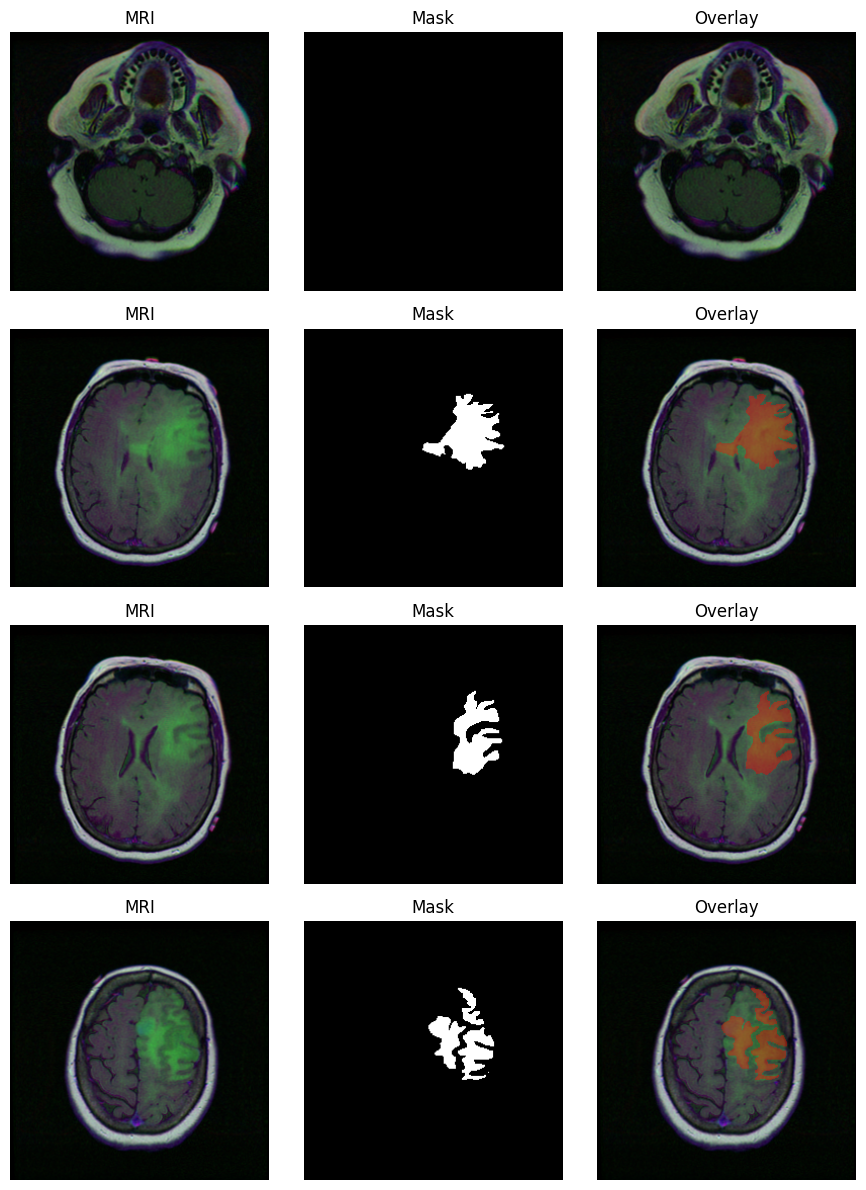

In [10]:
def plot_data(pairs, alpha=0.4):
    n = len(pairs)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))

    for i, (img_path, msk_path) in enumerate(pairs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)          # cv2 legge in BGR
        msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

        # overlay: the mask is red in the third column
        overlay = img.copy()
        overlay[msk > 0] = [255, 0, 0]
        blended = cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('MRI')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(msk, cmap='gray')
        axes[i, 1].set_title('Mask')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(blended)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

pairs = list(zip(df['images_paths'], df['masks_paths']))
plot_data(pairs[1:5])

### 2.5 Train / validation / test split 
First hold out 70% for training and 30% for the rest, then halve that remainder into validation and test sets.

In [11]:
# create training dataframe
train_df, val_test_df = train_test_split(df, random_state = RANDOM_STATE, train_size= TRAIN_SPLIT)

# create validation and test dataframe
val_df, test_df = train_test_split(val_test_df, train_size= TEST_SPLIT)


### 2.6 Data Generator
A batch generator streams the pairs from disk on the fly

**Batch generator:** builds a generator of aligned (image, mask) batches: each image and its mask receive identical geometric transforms.

In [12]:
def get_generator(df, size=256, batch_size=40, augment=False, aug_config = {}):
    rows = df[['images_paths', 'masks_paths']].to_numpy()
    
    datagen = ImageDataGenerator(**aug_config)   

    while True:
        np.random.shuffle(rows)
        for k in range(0, len(rows) - batch_size + 1, batch_size):
            X, Y = [], []
            for ip, mp in rows[k:k+batch_size]:
                img = cv2.resize(cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB), (size, size)).astype('float32')
                msk = cv2.resize(cv2.imread(mp, cv2.IMREAD_GRAYSCALE), (size, size),
                                 interpolation=cv2.INTER_NEAREST).astype('float32')[..., None]
                if augment:
                    t = datagen.get_random_transform(img.shape)   # get transformation
                    img = datagen.apply_transform(img, t)          
                    msk = datagen.apply_transform(msk, t)          
                X.append(img / 255.0)
                Y.append((msk > 127).astype('float32'))
            yield np.stack(X), np.stack(Y)

**Create the generators:** training gets light augmentation (rotation, shifts, shear, zoom, horizontal flip) to fight overfitting; validation and test don't use augmentation` to stay faithful to the original images.

In [ ]:
img_size = 256
batch_size = 40

train_aug = dict(rotation_range=10,
                 width_shift_range=0.10,
                 height_shift_range=0.10,
                 shear_range=0.05,
                 zoom_range=0.15,
                 horizontal_flip=True,
                 fill_mode='nearest')

train_gen = get_generator(train_df, img_size, batch_size, augment=True, aug_config=train_aug)
val_gen = get_generator(val_df, img_size, batch_size, augment=False)
test_gen = get_generator(test_df, img_size, batch_size, augment=False)

## **3. Metrics**

In [2]:
# function to create dice coefficient
def dice_coef(y_true, y_pred, smooth=100):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)

    intersection = K.sum(y_true_flatten * y_pred_flatten)
    union = K.sum(y_true_flatten) + K.sum(y_pred_flatten)
    return (2 * intersection + smooth) / (union + smooth)

# function to create dice loss
def dice_loss(y_true, y_pred, smooth=100):
    return -dice_coef(y_true, y_pred, smooth)

# function to create iou coefficient
def iou_coef(y_true, y_pred, smooth=100):
    intersection = K.sum(y_true * y_pred)
    sum = K.sum(y_true + y_pred)
    iou = (intersection + smooth) / (sum - intersection + smooth)
    return iou

## **4. Model**

In [ ]:
def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    
    return x

def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)

    skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(skip_features)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

def unet(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Contracting Path (Encoder)
    s1 = encoder_block(inputs, 64)
    s2 = encoder_block(s1, 128)
    s3 = encoder_block(s2, 256)
    s4 = encoder_block(s3, 512)
    
    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(s4)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    
    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='valid', activation='sigmoid')(d4)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

In [ ]:
model = unet()
model.compile(Adamax(learning_rate= 0.001), loss= dice_loss, metrics= ['accuracy', iou_coef, dice_coef])

model.summary()

## Model training

In [4]:
def plot_train(hist):
    """Andamento di loss e metriche per epoca, con l'epoca migliore evidenziata su ogni pannello."""
    history = hist.history
    epochs = range(1, len(history['loss']) + 1)

    # (chiave train, chiave val, etichetta, criterio) — 'max' per le metriche, 'min' per la loss
    panels = [
        ('iou_coef',  'val_iou_coef',  'IoU',      'max'),
        ('dice_coef', 'val_dice_coef', 'Dice',     'max'),
        ('loss',      'val_loss',      'Loss',     'min'),
        ('accuracy',  'val_accuracy',  'Accuracy', 'max'),
    ]

    plt.style.use('fivethirtyeight')
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    for ax, (tr_key, val_key, name, criterion) in zip(axes.flat, panels):
        tr_curve, val_curve = history[tr_key], history[val_key]

        # epoca migliore scelta sul validation, coerente col criterio del pannello
        pick = np.argmin if criterion == 'min' else np.argmax
        best = int(pick(val_curve))

        ax.plot(epochs, tr_curve,  color='crimson',  linewidth=2, label=f'Train {name}')
        ax.plot(epochs, val_curve, color='seagreen', linewidth=2, label=f'Validation {name}')
        ax.scatter(best + 1, val_curve[best], s=140, color='navy', zorder=5,
                   label=f'Best epoch: {best + 1}')

        ax.set(title=f'{name}', xlabel='Epoch', ylabel=name)
        ax.legend()
    
    fig.suptitle('Training vs Validation History Metrics', fontsize=16, fontweight='bold')
    fig.tight_layout()
    plt.show()

In [ ]:
epochs = 70
batch_size = 40
callbacks = [ModelCheckpoint('unet.keras', verbose=0, save_best_only=True)]

history = model.fit(train_gen,
                    steps_per_epoch=len(train_df) // batch_size,
                    epochs=epochs,
                    verbose=1,
                    callbacks=callbacks,
                    validation_data = val_gen,
                    validation_steps=len(val_df) // batch_size)

In [ ]:
plot_train(history)

## Load model (optional)

Once you have fully run the notebook and obtained the `unet.keras` file, you can upload the model as follows:

1. In the **Input** section, click **Upload**.
2. Select **New Model**.
3. Browse for the file (if you saved the model on your PC); otherwise, you can choose one of the other available options.
4. Fill in the form: choose **Keras** for the framework, and set the other fields as you prefer.
5. Click **Create** and wait for the system to finish uploading.
6. Go to the **Models** section and find the `unet.keras` file. You can copy its file path by clicking on the right button.
7. Paste the file path into the `model_path` variable.

In [17]:
# Uncomment if you need to use this section

"""
model_path = "/kaggle/input/models/.../model-checkpoint/keras/default/1/unet.keras"

model = keras.models.load_model(
    model_path,
    compile=False
)
model.compile(
    optimizer="adam",
    loss=dice_loss,
    metrics=["accuracy", iou_coef, dice_coef],   # usa i nomi ESATTI delle tue metriche
)
"""

## Evaluation

In [18]:
def load_split(df, size=256):
    X, Y = [], []
    for ip, mp in df[['images_paths', 'masks_paths']].to_numpy():
        img = cv2.resize(cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB), (size, size))
        msk = cv2.resize(cv2.imread(mp, cv2.IMREAD_GRAYSCALE), (size, size),
                         interpolation=cv2.INTER_NEAREST)
        X.append(img.astype('float32') / 255.0)
        Y.append((msk > 127).astype('float32')[..., None])
    return np.stack(X), np.stack(Y)

X_test, Y_test = load_split(test_df)
test_eval = model.evaluate(X_test, Y_test, batch_size=32, verbose=1, return_dict=True)

print("Test Set Loss:", test_eval["loss"])
print("Test Set Accuracy:", test_eval["accuracy"])
print("Test Set IoU:", test_eval["iou_coef"])
print("Test Set Dice:", test_eval["dice_coef"])

37/37 ━━━━━━━━━━━━━━━━━━━━ 1145s 31s/step - accuracy: 0.9982 - dice_coef: 0.9142 - iou_coef: 0.8432 - loss: -0.9141
Loss: -0.914066731929779
Accuracy: 0.9981695413589478


KeyError: 'iou'

## Prediction

Many of the MRI images don't contain any tumor. To show meaningful predictions, I selected some specific indices that retrieve examples where a tumor mask is actually present. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step


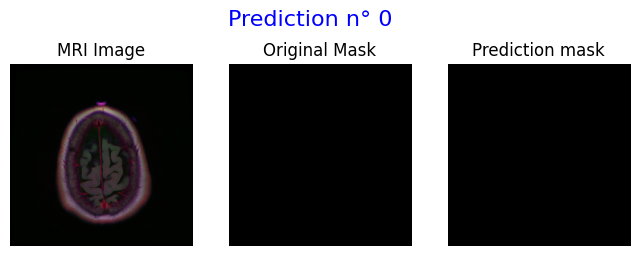

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


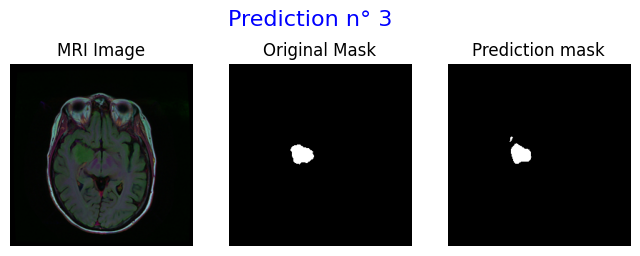

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step


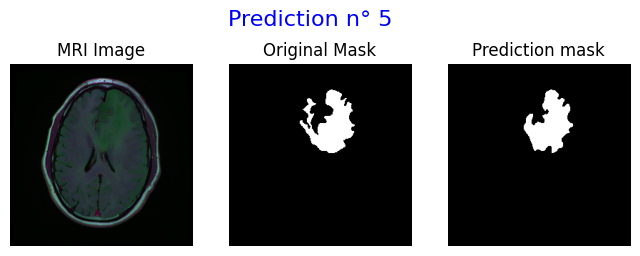

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step


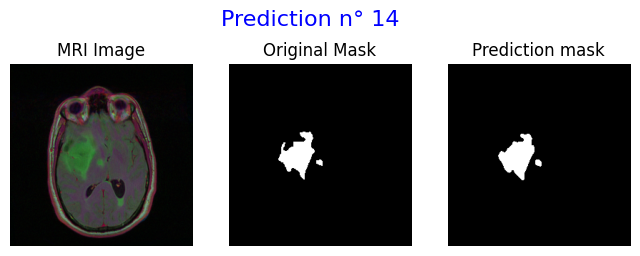

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step


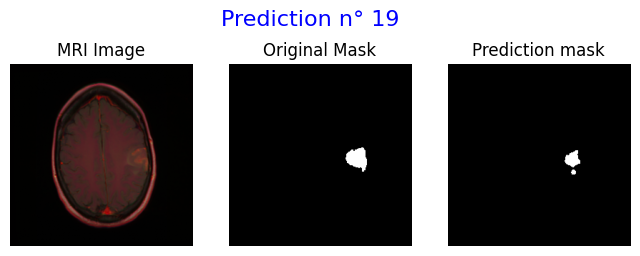

In [38]:
index_list = [0,3,5,14,19]
for i in index_list:
    
    # MRI image
    img = cv2.imread(test_df['images_paths'].iloc[i])
    img = cv2.resize(img, (256, 256))
    img = img/255
    img = img[np.newaxis, :, :, : ]
    mri_img = np.squeeze(img)

    # Original mask
    orig_mask = np.squeeze(cv2.imread(test_df['masks_paths'].iloc[i]))
    
    # Prediction img
    predict_mask = model.predict(img)
    predict_mask = ((np.squeeze(predict_mask) > 0.5 ) * 255).astype(np.uint8)

    plt.figure(figsize=(8, 3))
    plt.suptitle(f"Prediction n° {i}", fontsize = 16, color = "blue")
    
    plt.subplot(1, 3, 1)
    plt.imshow(mri_img)
    plt.title('MRI Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(orig_mask)
    plt.title('Original Mask')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(predict_mask, cmap = "grey")
    plt.title('Prediction mask')
    plt.axis('off')
    
    plt.show()


## References

This dataset is used in:

- Mateusz Buda, Ashirbani Saha, Maciej A. Mazurowski. *"Association of genomic subtypes of lower-grade gliomas with shape features automatically extracted by a deep learning algorithm."* Computers in Biology and Medicine, 2019.
- Maciej A. Mazurowski, Kal Clark, Nicholas M. Czarnek, Parisa Shamsesfandabadi, Katherine B. Peters, Ashirbani Saha. *"Radiogenomics of lower-grade glioma: algorithmically-assessed tumor shape is associated with tumor genomic subtypes and patient outcomes in a multi-institutional study with The Cancer Genome Atlas data."* Journal of Neuro-Oncology, 2017.